In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

print(f"Shape X: {X.shape}")  
print(f"Shape y: {y.shape}")  
print(f"Classes: {np.unique(y)}")

Shape X: (70000, 784)
Shape y: (70000,)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [ ]:

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (60000, 784), Test: (10000, 784)


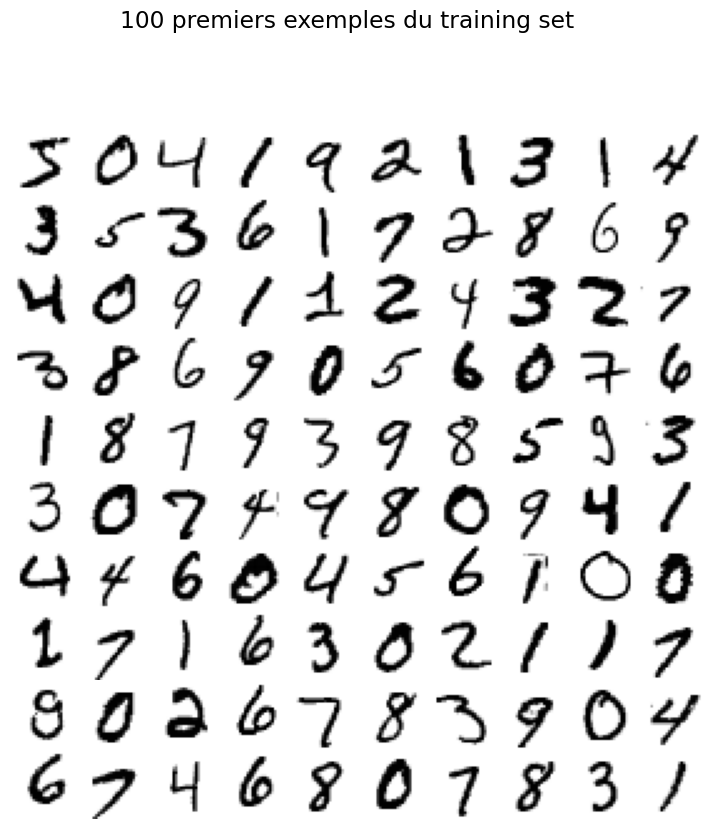

In [ ]:

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X_train[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.suptitle("100 premiers exemples du training set", y=1.01)
plt.show()

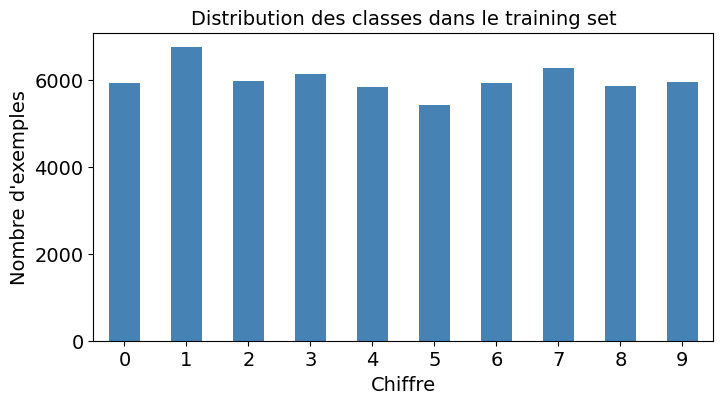

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [ ]:
import pandas as pd

class_counts = pd.Series(y_train).value_counts().sort_index()
class_counts.plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Distribution des classes dans le training set")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=0)
plt.show()

print(class_counts)

In [ ]:
print(f"Valeur min des pixels : {X_train.min()}")
print(f"Valeur max des pixels : {X_train.max()}")
print(f"Moyenne : {X_train.mean():.2f}")
print(f"% de pixels noirs (=0) : {(X_train == 0).mean()*100:.1f}%")

Valeur min des pixels : 0
Valeur max des pixels : 255
Moyenne : 33.32
% de pixels noirs (=0) : 80.9%


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(float))
X_test_scaled  = scaler.transform(X_test.astype(float))

Avant scaling - mean: 33.32 std: 78.57
Après scaling - mean: -0.0 std: 0.96


In [7]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

models = {
    "SGD":           SGDClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":           KNeighborsClassifier(n_neighbors=4),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring="accuracy")
    results[name] = scores
    print(f"{name:20s} → {scores.mean():.4f} ± {scores.std():.4f}")

SGD                  → 0.8970 ± 0.0045
Random Forest        → 0.9645 ± 0.0016
KNN                  → 0.9373 ± 0.0016


/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_5695/3232394692.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys())


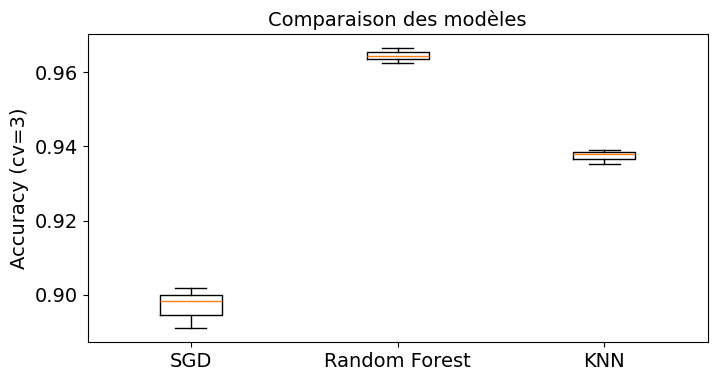

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), labels=results.keys())
ax.set_ylabel("Accuracy (cv=3)")
ax.set_title("Comparaison des modèles")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [3, 4, 5],
    "weights": ["uniform", "distance"],
}

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=3, scoring="accuracy", verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV    :", grid_search.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres : {'n_neighbors': 4, 'weights': 'distance'}
Meilleur score CV    : 0.9437666666666668


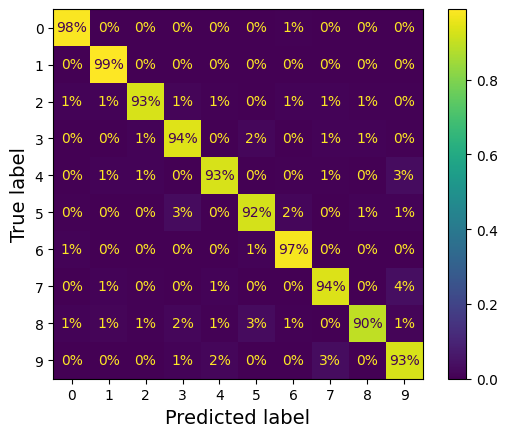

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

best_model = grid_search.best_estimator_


y_train_pred = cross_val_predict(best_model, X_train_scaled, y_train, cv=3)
plt.rc('font', size=10) 
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

In [19]:
from scipy.ndimage import shift
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

In [20]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [21]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [22]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [23]:
knn_clf.fit(X_train_augmented, y_train_augmented)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

0.9763

In [26]:
from sklearn.metrics import accuracy_score, classification_report
y_test_pred = knn_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy finale sur le test set : {test_accuracy:.4f}")
print()
print(classification_report(y_test, y_test_pred))

Accuracy finale sur le test set : 0.9763

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.99       958
           7       0.97      0.97      0.97      1028
           8       0.99      0.95      0.97       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



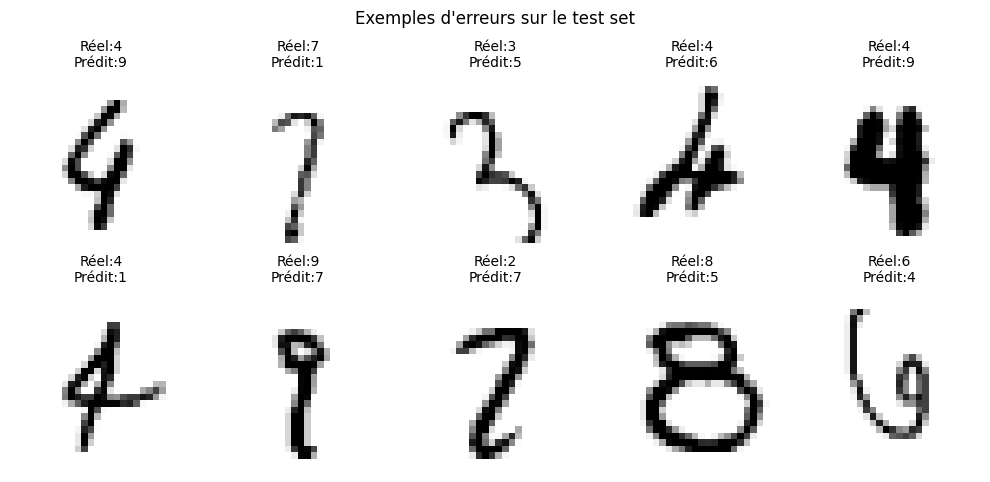

In [28]:
errors_idx = np.where(y_test_pred != y_test)[0]

plt.figure(figsize=(10, 5))
for i, idx in enumerate(errors_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plot_digit(X_test[idx])
    plt.title(f"Réel:{y_test[idx]}\nPrédit:{y_test_pred[idx]}", fontsize=10)
plt.suptitle("Exemples d'erreurs sur le test set")
plt.tight_layout()
plt.show()

In [29]:
import joblib
from datetime import datetime

joblib.dump(best_model, "mnist_knn_model.pkl")
joblib.dump(scaler, "mnist_scaler.pkl")

def predict_digit(raw_image):

    model = joblib.load("mnist_knn_model.pkl")
    scaler = joblib.load("mnist_scaler.pkl")
    image_scaled = scaler.transform([raw_image.astype(float)])
    return model.predict(image_scaled)[0]

# Test
sample = X_test[0]
prediction = predict_digit(sample)
print(f"Image réelle : {y_test[0]} | Prédiction : {prediction}")

Image réelle : 7 | Prédiction : 7
